<a href="https://colab.research.google.com/github/Linkhardy/KnowledgeNetPublic/blob/main/app_circle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import sys

# 1. Prüfen, ob wir in der Google Colab Umgebung sind
if 'google.colab' in str(get_ipython()):
    print("Läuft in Colab - Verknüpfung mit GitHub wird hergestellt...")

    # Pfad zum Repo-Ordner definieren
    repo_path = 'KnowledgeNetPublic'

    # Repo klonen, falls es noch nicht da ist
    if not os.path.exists(repo_path):
        !git clone https://github.com/Linkhardy/KnowledgeNetPublic.git
    else:
        # Falls es schon da ist, ziehen wir die neuesten Änderungen (Update)
        %cd {repo_path}
        !git pull
        %cd ..

    # Den /modules Ordner für Python sichtbar machen
    module_path = os.path.join(os.getcwd(), repo_path, 'modules')
    if module_path not in sys.path:
        sys.path.append(module_path)

    print(f"Erfolg! Module werden nun aus {module_path} geladen.")
else:
    print("Läuft lokal - stelle sicher, dass der /modules Ordner im selben Verzeichnis liegt.")

Läuft in Colab - Verknüpfung mit GitHub wird hergestellt...
Cloning into 'KnowledgeNetPublic'...
remote: Enumerating objects: 58, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 58 (delta 20), reused 38 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (58/58), 237.72 KiB | 3.09 MiB/s, done.
Resolving deltas: 100% (20/20), done.
Erfolg! Module werden nun aus /content/KnowledgeNetPublic/modules geladen.


/usr/local/lib/python3.12/dist-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


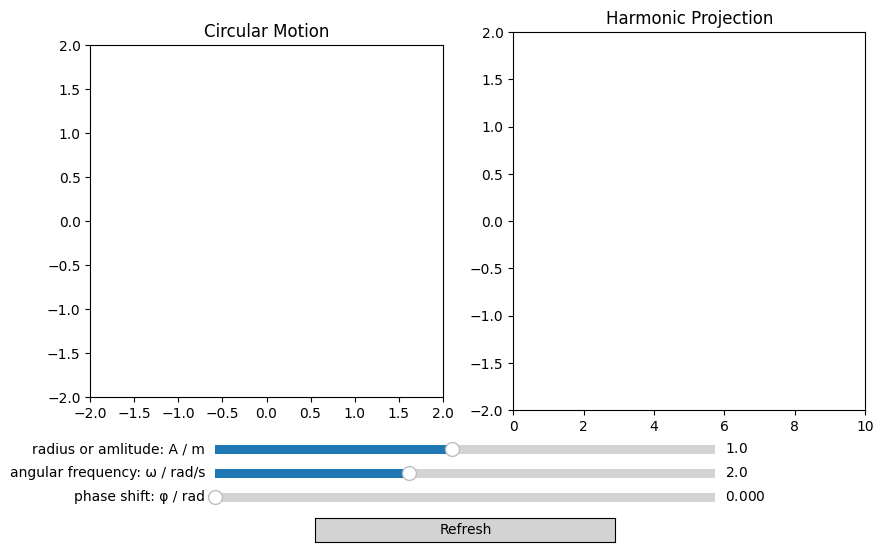

In [3]:
# -*- coding: utf-8 -*-
"""
Created on Mon Mar 23 08:11:40 2026

@author: FuchsbergerKai
"""

# app_circle.py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
import ipywidgets as widgets
import os

# --- 1. Import deiner Module aus GitHub ---
# (Stelle sicher, dass die Infrastruktur-Zelle vorher gelaufen ist!)
from models import circular
from animation import Animator # Behalten wir für die Logik, falls nötig
from components import CirclePlot, OscillatorPlot

def run_simulation(R=1.0, omega=2.0, phi=0.0):
    """
    Diese Funktion wird jedes Mal aufgerufen, wenn du einen Slider bewegst.
    Sie erstellt die Figure, die Animation und zeigt sie an.
    """
    # --- Setup ---
    dt = 0.05
    t_data = []
    y_data = []

    # --- Figure & Axes (Neu erstellt für sauberes Rendering) ---
    fig = plt.figure(figsize=(10, 5))
    ax_circle = fig.add_subplot(1, 2, 1)
    ax_wave = fig.add_subplot(1, 2, 2)
    plt.close() # Verhindert, dass Colab ein leeres Standbild vorab zeigt

    # Achsen-Styling
    ax_circle.set_xlim(-2, 2)
    ax_circle.set_ylim(-2, 2)
    ax_circle.set_aspect('equal')
    ax_circle.set_title("Circular Motion")

    ax_wave.set_xlim(0, 10)
    ax_wave.set_ylim(-2, 2)
    ax_wave.set_title("Harmonic Projection")

    # --- Deine Komponenten initialisieren ---
    circle_plot = CirclePlot(ax_circle, R=R)
    osc_plot = OscillatorPlot(ax_wave)

    # --- Update-Logik für die Animation ---
    def update(frame):
        t = frame * dt

        # Berechnung über dein Modul
        x, y = circular(t, R=R, omega=omega, phi=phi)

        # Update Circle
        circle_plot.update(x, y)

        # Update Wave Data
        t_data.append(t)
        y_data.append(y)

        # Sliding Window (wie in deinem Original)
        if len(t_data) > 200:
            t_data.pop(0)
            y_data.pop(0)

        osc_plot.update(t_data, y_data)
        ax_wave.set_xlim(max(0, t - 10), t + 0.1)

        return []

    # --- Animation erstellen ---
    # Wir nutzen 200 Frames für eine flüssige Vorschau im Browser
    anim = FuncAnimation(fig, update, frames=200, interval=50, blit=False)

    # --- Umgebungs-Weiche ---
    if 'google.colab' in str(get_ipython()):
        # In Colab als HTML5 Video anzeigen
        return display(HTML(anim.to_html5_video()))
    else:
        # Lokal (Windows/Ubuntu) klassisch anzeigen
        plt.show()
        return None

# --- DER INTERAKTIVE CONTROLLER (Ersetzt deine alten Slider) ---
print("Interaktive Simulation: Ändere die Werte, um die Animation neu zu starten.")
widgets.interact(run_simulation,
                 R=widgets.FloatSlider(value=1.0, min=0.1, max=2.0, step=0.1, description='Radius A:'),
                 omega=widgets.FloatSlider(value=2.0, min=0.1, max=5.0, step=0.1, description='Frequenz ω:'),
                 phi=widgets.FloatSlider(value=0.0, min=0.0, max=6.28, step=0.1, description='Phase φ:'))
